- notebook to cross check the NuFast engine producing the same plots in explorer.ipynb
- this notebook primarily focuses on the NOvA experiment. 


In [14]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt 

from nuosclab import ExplorerConfig, compute_curves

In [15]:
## physics calculation/plot for the nova experiment.
config = ExplorerConfig(
    experiment="NOvA",
    engine="numpy_ref",
    antineutrino=False,
    n_points=400,
)

In [16]:
curves = compute_curves(config)
##finds the nova preset and creates 400 evenly space energy.
##from the engines.py, get teh numpy_ref, which sends all the
## parameters of teh experimetn to that engine.
##computes the probability and results in curve.

In [17]:
print(curves.energy_gev.shape) #prints the type of array(1D)
print(curves.live.shape) #prints the type of array(3D)
#curves.live uses PMNS and NSI values in 'config', this is from core.py
print(curves.preset)

(400,)
(400, 3, 3)
ExperimentPreset(name='NOvA', L_km=810, rho_gcc=2.79, E_range=(0.3, 5.0), E_peak=1.9)


In [18]:
energy = curves.energy_gev

p_mu_to_e = curves.live[:, 0, 1]## first to last energy, final, initial
p_mu_to_mu = curves.live[:, 1, 1]
# 0 -> electron
# 1 -> muon
## initial flavor muon to  final flavor electron. (appereance)
## or initial flavor muon to final flavor muon. (survival)

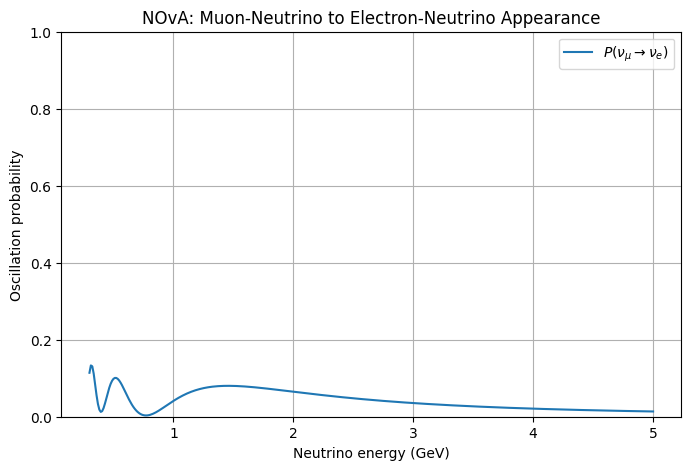

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    energy,
    p_mu_to_e,
    label = r"$P(\nu_\mu \rightarrow \nu_e)$",
)

plt.xlabel("Neutrino energy (GeV)")
plt.ylabel("Oscillation probability")
plt.title("NOvA: Muon-Neutrino to Electron-Neutrino Appearance")
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()

## Graph meaning:
- horizontal axis represents the energy.
- vertical axis represents the probability which should be 0 <= P <= 1.

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    energy,
    p_mu_to_mu,
    label=r"$P(\nu_\mu \rightarrow \nu_\mu)$",
)

plt.xlabel("Neutrino energy (GeV)")
plt.ylabel("Oscillation probability")
plt.title("NOvA: Muon-Neutrino Survival")
plt.ylim(0, 1)
plt.grid()
plt.legend()
plt.show()